# Fase 2: Benchmarking de Modelos Avanzados — Random Forest vs. MLP
**Curso:** AI Impact Analysis in Business  
**Objetivo:** Superar el baseline de Regresión Logística (AUC 0.714 / F1-Macro 0.59)  
**Marco de decisión:** Toda elección técnica se justifica por su impacto en la cartera del banco

## 0. Imports y configuración global

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from scipy.stats import randint, uniform

# ── Configuración global ──────────────────────────────────────────────────────
SEED        = 42
N_JOBS      = -1            # Usa todos los cores disponibles
np.random.seed(SEED)

# ── Rutas ─────────────────────────────────────────────────────────────────────
DIR_PROCESSED = os.path.join('data', 'processed')

# ── Resultados del baseline (Logistic Regression — Fase 1) ───────────────────
# Estos valores sirven como línea de referencia para el dashboard comparativo.
BASELINE = {
    'nombre'    : 'Logistic Regression (Baseline)',
    'auc_roc'   : 0.714,
    'pr_auc'    : 0.393,
    'f1_macro'  : 0.59,
    'recall_1'  : 0.67,
    'precision_1': 0.33,
    'fp'        : 77503,
    'fn'        : 19066,
}

print("Configuración cargada.")
print(f"  Directorio de datos:   {DIR_PROCESSED}/")
print(f"  Baseline a superar — AUC: {BASELINE['auc_roc']} | F1-Macro: {BASELINE['f1_macro']} | Recall-1: {BASELINE['recall_1']}")


Configuración cargada.
  Directorio de datos:   data\processed/
  Baseline a superar — AUC: 0.714 | F1-Macro: 0.59 | Recall-1: 0.67


## 1. Carga de datos y estrategia de muestreo

Los datos de la Fase 1 ya están procesados y listos en `data/processed/`. Cargamos directamente los cuatro artefactos sin necesidad de re-ejecutar el pipeline de preprocesamiento.

### Estrategia de muestreo para el tuning
Con 1.1M filas en train, un `GridSearchCV` completo con 5 folds tardaría **horas**. La estrategia profesional es:
1. **Tuning rápido** sobre un 15% estratificado del train (~165k filas) para explorar el espacio de hiperparámetros.
2. **Re-entrenamiento final** del mejor modelo con el **100% del train** antes de evaluar en test.
3. **Evaluación siempre sobre el test completo** (273k filas) para garantizar estimaciones no sesgadas.

In [2]:
print("Cargando datos procesados de la Fase 1...")
t0 = time.time()

X_train = pd.read_csv(os.path.join(DIR_PROCESSED, 'X_train.csv'))
X_test  = pd.read_csv(os.path.join(DIR_PROCESSED, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(DIR_PROCESSED, 'y_train.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(DIR_PROCESSED, 'y_test.csv')).squeeze()

print(f"Carga completada en {time.time() - t0:.1f}s")
print(f"  X_train : {X_train.shape[0]:>10,} filas × {X_train.shape[1]} features")
print(f"  X_test  : {X_test.shape[0]:>10,} filas × {X_test.shape[1]} features")
print(f"  Default en train: {y_train.mean():.2%} | Default en test: {y_test.mean():.2%}")

# ── Submuestra estratificada para el tuning ───────────────────────────────────
# train_size=0.15 → ~165k filas; stratify garantiza el mismo 21% de defaults.
FRACCION_TUNING = 0.15

X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    train_size=FRACCION_TUNING,
    random_state=SEED,
    stratify=y_train,
)

print(f"\nSubmuestra de tuning: {X_tune.shape[0]:,} filas ({FRACCION_TUNING:.0%} del train)")
print(f"  Default en submuestra: {y_tune.mean():.2%} ✓ (proporciones preservadas)")


Cargando datos procesados de la Fase 1...
Carga completada en 12.1s
  X_train :  1,095,652 filas × 44 features
  X_test  :    273,914 filas × 44 features
  Default en train: 21.23% | Default en test: 21.24%

Submuestra de tuning: 164,347 filas (15% del train)
  Default en submuestra: 21.23% ✓ (proporciones preservadas)


## 2. Modelo A: Random Forest

### ¿Por qué Random Forest como primer candidato?

El Random Forest es la elección natural para superar un modelo lineal en datos financieros:
- **Captura no linealidades:** La relación DTI–default no es lineal (un DTI de 40% no es exactamente el doble de riesgoso que uno de 20%).
- **Robusto al ruido:** El bagging promedia el error de miles de árboles, reduciendo la varianza.
- **Nativo para desbalanceo:** `class_weight='balanced'` ajusta los pesos sin oversampling.
- **Interpretabilidad:** Las importancias de Gini permiten explicar el modelo a un comité de riesgos.

### Espacio de búsqueda con `RandomizedSearchCV`
Usamos `RandomizedSearchCV` en lugar de `GridSearchCV` porque:
- Con 6 hiperparámetros y rangos amplios, `GridSearch` exploraría miles de combinaciones.
- `RandomizedSearchCV` con `n_iter=30` muestrea aleatoriamente 30 combinaciones, cubriendo el espacio de forma eficiente en una fracción del tiempo.

In [3]:
# ── Espacio de hiperparámetros para Random Forest ────────────────────────────
# Cada parámetro tiene una justificación de negocio o técnica:
#
#   n_estimators     : más árboles = más estable, pero rendimiento marginal decreciente
#   max_depth        : None = árbol completo (riesgo de overfitting) vs. limitado
#   min_samples_leaf : mínimo de muestras en hoja → principal control del overfitting
#   max_features     : proporción de features por split → diversidad entre árboles
#   class_weight     : 'balanced' o ratio explícito para el desbalanceo 79/21
param_dist_rf = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : [6, 10, 15, 20, None],
    'min_samples_leaf': randint(10, 100),
    'max_features'    : ['sqrt', 0.2, 0.3, 0.4],
    'class_weight'    : ['balanced', {0: 1, 1: 3}, {0: 1, 1: 4}],
    'bootstrap'       : [True, False],
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_base = RandomForestClassifier(random_state=SEED, n_jobs=N_JOBS)

search_rf = RandomizedSearchCV(
    estimator   = rf_base,
    param_distributions = param_dist_rf,
    n_iter      = 30,           # 30 combinaciones aleatorias
    scoring     = 'f1_macro',   # Métrica objetivo del negocio
    cv          = cv_strat,
    n_jobs      = N_JOBS,
    random_state= SEED,
    verbose     = 1,
    refit       = True,         # Refit automático con los mejores params
)

print("Iniciando RandomizedSearchCV sobre Random Forest...")
print(f"  Dataset de tuning: {X_tune.shape[0]:,} filas | 30 iteraciones × 5 folds = 150 ajustes")
t0 = time.time()

search_rf.fit(X_tune, y_tune)

elapsed_rf = (time.time() - t0) / 60
print(f"\nTuning completado en {elapsed_rf:.1f} min")
print(f"Mejores hiperparámetros: {search_rf.best_params_}")
print(f"Mejor F1-Macro en CV:    {search_rf.best_score_:.4f}")


Iniciando RandomizedSearchCV sobre Random Forest...
  Dataset de tuning: 164,347 filas | 30 iteraciones × 5 folds = 150 ajustes
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tuning completado en 98.8 min
Mejores hiperparámetros: {'bootstrap': True, 'class_weight': {0: 1, 1: 3}, 'max_depth': 15, 'max_features': 0.3, 'min_samples_leaf': 84, 'n_estimators': 187}
Mejor F1-Macro en CV:    0.6254


In [4]:
# ── Re-entrenamiento final con el 100% del train ─────────────────────────────
# El modelo ganador del tuning se re-entrena con todos los datos de train para
# maximizar la información disponible antes de evaluar en test.
print("Re-entrenando Random Forest con los mejores hiperparámetros y el 100% del train...")
t0 = time.time()

rf_final = RandomForestClassifier(
    **search_rf.best_params_,
    random_state=SEED,
    n_jobs=N_JOBS,
)
rf_final.fit(X_train, y_train)

print(f"Re-entrenamiento completado en {(time.time() - t0)/60:.1f} min")

# ── Predicciones sobre el test completo ───────────────────────────────────────
y_prob_rf  = rf_final.predict_proba(X_test)[:, 1]
y_pred_rf  = rf_final.predict(X_test)

print("\nReporte con umbral 0.5 (referencia):")
print(classification_report(y_test, y_pred_rf, target_names=['Pagador (0)', 'Moroso (1)']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_rf):.4f}")


Re-entrenando Random Forest con los mejores hiperparámetros y el 100% del train...
Re-entrenamiento completado en 6.5 min

Reporte con umbral 0.5 (referencia):
              precision    recall  f1-score   support

 Pagador (0)       0.86      0.76      0.81    215748
  Moroso (1)       0.38      0.55      0.45     58166

    accuracy                           0.71    273914
   macro avg       0.62      0.65      0.63    273914
weighted avg       0.76      0.71      0.73    273914

AUC-ROC: 0.7228
PR-AUC:  0.4093


### 2.1 Importancia de Variables — Random Forest

El Random Forest ofrece importancias basadas en la **reducción media de impureza de Gini**, una métrica mucho más robusta que los coeficientes de la Regresión Logística en presencia de multicolinealidad.

**¿Por qué es más fiable que los coeficientes?** Mientras que la Regresión Logística "se confunde" con variables correlacionadas (como vimos con `fico_range_low` y `fico_range_high`), el Random Forest distribuye la importancia naturalmente entre variables colineales sin producir signos contraintuitivos.

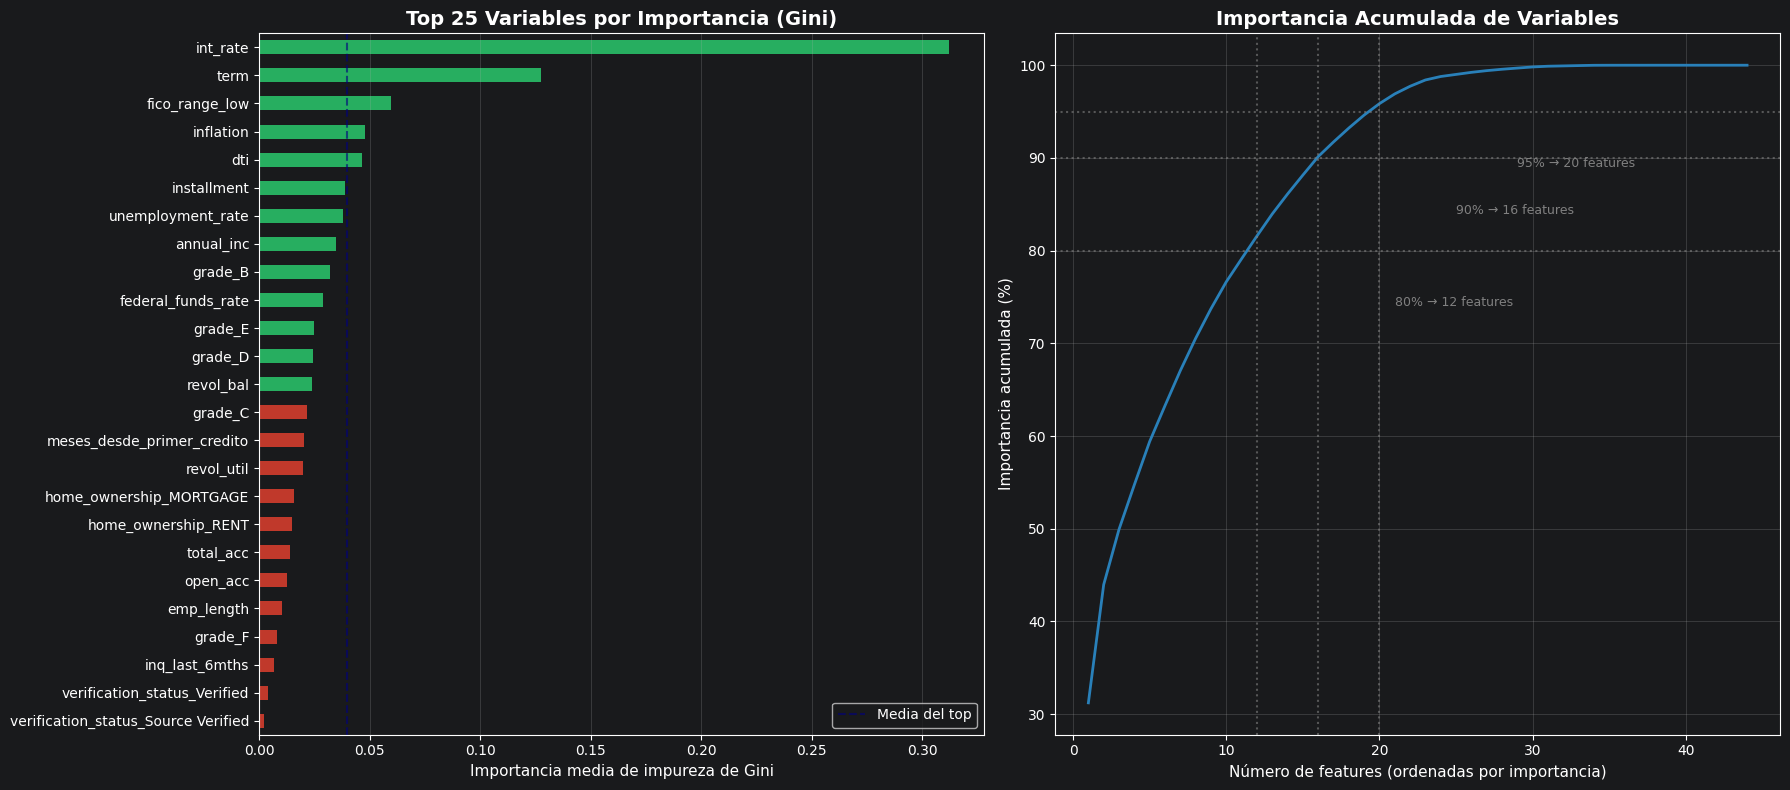


Top 10 variables más importantes:
   1. int_rate                            0.3122 (31.2%)
   2. term                                0.1275 (12.7%)
   3. fico_range_low                      0.0596 (6.0%)
   4. inflation                           0.0480 (4.8%)
   5. dti                                 0.0467 (4.7%)
   6. installment                         0.0386 (3.9%)
   7. unemployment_rate                   0.0378 (3.8%)
   8. annual_inc                          0.0348 (3.5%)
   9. grade_B                             0.0319 (3.2%)
  10. federal_funds_rate                  0.0291 (2.9%)


In [5]:
feat_imp = (
    pd.Series(rf_final.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

top_n = 25
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── Gráfico 1: Top 25 features ────────────────────────────────────────────────
colors = ['#c0392b' if v > feat_imp.iloc[top_n // 2] else '#27ae60'
          for v in feat_imp.head(top_n).values]

feat_imp.head(top_n).plot(kind='barh', color=colors[::-1], ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title(f'Top {top_n} Variables por Importancia (Gini)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importancia media de impureza de Gini', fontsize=11)
axes[0].axvline(feat_imp.head(top_n).mean(), color='navy', linestyle='--',
                alpha=0.6, label='Media del top')
axes[0].legend(fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# ── Gráfico 2: Curva de importancia acumulada ─────────────────────────────────
cumsum = feat_imp.values.cumsum() / feat_imp.values.sum() * 100
axes[1].plot(range(1, len(cumsum) + 1), cumsum, color='#2980b9', lw=2)
for pct in [80, 90, 95]:
    idx = next(i for i, v in enumerate(cumsum) if v >= pct)
    axes[1].axhline(pct, color='grey', linestyle=':', alpha=0.6)
    axes[1].axvline(idx + 1, color='grey', linestyle=':', alpha=0.6)
    axes[1].annotate(f'{pct}% → {idx+1} features',
                     xy=(idx + 1, pct), xytext=(idx + 10, pct - 6),
                     fontsize=9, color='grey')
axes[1].set_title('Importancia Acumulada de Variables', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de features (ordenadas por importancia)', fontsize=11)
axes[1].set_ylabel('Importancia acumulada (%)', fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 10 variables más importantes:")
for i, (feat, val) in enumerate(feat_imp.head(10).items(), 1):
    print(f"  {i:>2}. {feat:<35} {val:.4f} ({val/feat_imp.sum()*100:.1f}%)")


## 3. Modelo B: Multi-Layer Perceptron (MLP)

### ¿Por qué una Red Neuronal para datos tabulares?

El MLP complementa al Random Forest porque:
- **Captura interacciones de orden superior:** Puede aprender que el riesgo de un cliente con DTI alto *y* FICO bajo *y* desempleo creciente es mayor que la suma de los efectos individuales.
- **Generalización suave:** A diferencia de los árboles (que memorizan fronteras de decisión angulares), el MLP aprende fronteras suaves que pueden generalizar mejor en zonas de datos escasos.
- **Sensible al escalado:** Justamente por esto usamos `RobustScaler` en la Fase 1 — las activaciones de las capas ocultas se estabilizan con datos bien escalados.

### Arquitectura elegida
Para datos tabulares financieros con ~44 features, la literatura empírica sugiere:
- **2–3 capas ocultas** con reducción progresiva de neuronas (funnel architecture).
- **Activación ReLU** como candidato principal (no sufre vanishing gradient, entrena rápido).
- **Early stopping:** Detiene el entrenamiento si el loss de validación no mejora → previene overfitting automáticamente sin necesidad de definir `max_iter` exacto.
- **Regularización L2 (alpha):** El hiperparámetro más crítico para evitar overfitting en redes tabulares.

In [6]:
# ── Espacio de hiperparámetros para MLP ──────────────────────────────────────
# hidden_layer_sizes: arquitecturas tipo "funnel" (de ancho a estrecho)
#   → (256,128,64): red profunda para relaciones complejas
#   → (128,64):     equilibrio potencia/velocidad
#   → (64,32):      red pequeña como control de overfitting
#
# alpha: regularización L2. Rango 1e-4 a 1e-1 cubre desde muy laxa a muy estricta.
# learning_rate_init: tasa de aprendizaje inicial para Adam/SGD.
# activation: relu casi siempre gana en datos tabulares, tanh como alternativa suave.
param_dist_mlp = {
    'hidden_layer_sizes': [
        (256, 128, 64),
        (128, 64, 32),
        (128, 64),
        (64, 32),
        (256, 128),
        (512, 256, 128),
    ],
    'activation'         : ['relu', 'tanh'],
    'alpha'              : uniform(1e-4, 1e-1),   # L2 regularization
    'learning_rate_init' : uniform(1e-4, 5e-3),
    'batch_size'         : [256, 512, 1024],
}

mlp_base = MLPClassifier(
    solver         = 'adam',          # Adam converge más rápido que SGD en tabulares
    max_iter       = 200,
    early_stopping = True,            # Para automáticamente si val_loss no mejora
    validation_fraction = 0.1,        # 10% del train para early stopping
    n_iter_no_change    = 15,         # Paciencia: 15 épocas sin mejora → stop
    random_state   = SEED,
)

search_mlp = RandomizedSearchCV(
    estimator   = mlp_base,
    param_distributions = param_dist_mlp,
    n_iter      = 20,           # Menos iteraciones que RF por el coste computacional
    scoring     = 'f1_macro',
    cv          = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),  # 3-fold: más rápido
    n_jobs      = 1,            # MLP no paraleliza bien con n_jobs=-1 (GIL de Python)
    random_state= SEED,
    verbose     = 1,
    refit       = True,
)

print("Iniciando RandomizedSearchCV sobre MLP...")
print(f"  Dataset de tuning: {X_tune.shape[0]:,} filas | 20 iteraciones × 3 folds = 60 ajustes")
print("  (El MLP puede tardar más que el RF por el coste de backpropagation)")
t0 = time.time()

search_mlp.fit(X_tune, y_tune)

elapsed_mlp = (time.time() - t0) / 60
print(f"\nTuning completado en {elapsed_mlp:.1f} min")
print(f"Mejores hiperparámetros: {search_mlp.best_params_}")
print(f"Mejor F1-Macro en CV:    {search_mlp.best_score_:.4f}")


Iniciando RandomizedSearchCV sobre MLP...
  Dataset de tuning: 164,347 filas | 20 iteraciones × 3 folds = 60 ajustes
  (El MLP puede tardar más que el RF por el coste de backpropagation)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Tuning completado en 62.3 min
Mejores hiperparámetros: {'activation': 'relu', 'alpha': np.float64(0.042440148070636965), 'batch_size': 256, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': np.float64(0.0015674408735901907)}
Mejor F1-Macro en CV:    0.5474


In [7]:
# ── Re-entrenamiento final del MLP con el 100% del train ─────────────────────
print("Re-entrenando MLP con los mejores hiperparámetros y el 100% del train...")
t0 = time.time()

mlp_final = MLPClassifier(
    **search_mlp.best_params_,
    solver              = 'adam',
    max_iter            = 300,
    early_stopping      = True,
    validation_fraction = 0.05,    # 5% del train para early stopping en el refit completo
    n_iter_no_change    = 20,
    random_state        = SEED,
)
mlp_final.fit(X_train, y_train)

print(f"Re-entrenamiento completado en {(time.time() - t0)/60:.1f} min")
print(f"Épocas efectivas: {mlp_final.n_iter_} (detenido por early stopping)")

# ── Predicciones ───────────────────────────────────────────────────────────────
y_prob_mlp = mlp_final.predict_proba(X_test)[:, 1]
y_pred_mlp = mlp_final.predict(X_test)

print("\nReporte con umbral 0.5 (referencia):")
print(classification_report(y_test, y_pred_mlp, target_names=['Pagador (0)', 'Moroso (1)']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_mlp):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_mlp):.4f}")


Re-entrenando MLP con los mejores hiperparámetros y el 100% del train...
Re-entrenamiento completado en 10.2 min
Épocas efectivas: 47 (detenido por early stopping)

Reporte con umbral 0.5 (referencia):
              precision    recall  f1-score   support

 Pagador (0)       0.80      0.98      0.88    215748
  Moroso (1)       0.57      0.11      0.18     58166

    accuracy                           0.79    273914
   macro avg       0.69      0.54      0.53    273914
weighted avg       0.75      0.79      0.73    273914

AUC-ROC: 0.7263
PR-AUC:  0.4154


## 4. Optimización del Umbral de Decisión

### El umbral 0.5 es arbitrario — no es el óptimo de negocio

Por defecto, `predict()` clasifica como Default todo cliente cuya probabilidad supere 0.5. Este umbral maximiza la **accuracy global**, pero en un contexto bancario con desbalanceo 79/21, el coste de los errores no es simétrico:

| Error | Denominación técnica | Coste financiero |
|---|---|---|
| Aprobamos un moroso | Falso Positivo (FP) | Alto: perdemos el capital prestado |
| Rechazamos un buen cliente | Falso Negativo* (FN) | Moderado: perdemos el margen de intereses |

> *Nota de convención: en este proyecto, la clase 1 es "Default". Un "Falso Negativo" aquí significa que el modelo predijo "No Default" pero el cliente sí incumplió — es el error más caro para el banco.*

### Método de selección del umbral óptimo
Recorremos todos los umbrales posibles sobre la curva Precision-Recall y seleccionamos el que maximiza el **F1-score de la clase 1 (Default)**. Este criterio equilibra Recall (detectar morosos) y Precision (no rechazar buenos clientes en exceso).

In [8]:
def analizar_umbral(nombre, y_test, y_prob):
    """
    Analiza el impacto del umbral sobre las métricas de negocio.
    Retorna el umbral óptimo (max F1 clase 1) y las métricas asociadas.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

    # F1 para la clase 1 en cada umbral (excluimos el último punto donde recall=0)
    f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
    idx_opt   = f1_scores.argmax()
    thr_opt   = thresholds[idx_opt]

    # Rango de umbrales de interés para el banco (conservador a agresivo)
    umbrales_analisis = np.arange(0.30, 0.81, 0.05)
    resumen = []
    for thr in umbrales_analisis:
        y_pred_thr = (y_prob >= thr).astype(int)
        cm_thr     = confusion_matrix(y_test, y_pred_thr)
        tn, fp, fn, tp = cm_thr.ravel()
        resumen.append({
            'Umbral'  : round(thr, 2),
            'Recall-1': round(tp / (tp + fn + 1e-9), 3),
            'Prec-1'  : round(tp / (tp + fp + 1e-9), 3),
            'F1-1'    : round(2 * tp / (2 * tp + fp + fn + 1e-9), 3),
            'FP'      : fp,
            'FN'      : fn,
            'FP+FN'   : fp + fn,
        })

    df_res = pd.DataFrame(resumen)
    print(f"\n{'='*60}")
    print(f"  {nombre} — Análisis de Umbral")
    print(f"  Umbral óptimo (max F1 clase 1): {thr_opt:.3f}")
    print(f"{'='*60}")
    print(df_res.to_string(index=False))

    return thr_opt, df_res


print("Analizando umbrales para ambos modelos...")
thr_rf,  resumen_rf  = analizar_umbral('Random Forest', y_test, y_prob_rf,  '#c0392b')
thr_mlp, resumen_mlp = analizar_umbral('MLP',           y_test, y_prob_mlp, '#2980b9')


Analizando umbrales para ambos modelos...

  Random Forest — Análisis de Umbral
  Umbral óptimo (max F1 clase 1): 0.455
 Umbral  Recall-1  Prec-1  F1-1     FP    FN  FP+FN
   0.30     0.883   0.275 0.420 135433  6780 142213
   0.35     0.821   0.296 0.435 113653 10391 124044
   0.40     0.743   0.320 0.447  92041 14939 106980
   0.45     0.650   0.348 0.453  71003 20334  91337
   0.50     0.550   0.380 0.449  52261 26201  78462
   0.55     0.446   0.413 0.429  36781 32240  69021
   0.60     0.345   0.451 0.391  24381 38113  62494
   0.65     0.243   0.493 0.326  14521 44023  58544
   0.70     0.153   0.540 0.239   7593 49259  56852
   0.75     0.079   0.584 0.139   3264 53583  56847
   0.80     0.028   0.642 0.053    897 56554  57451

  MLP — Análisis de Umbral
  Umbral óptimo (max F1 clase 1): 0.234
 Umbral  Recall-1  Prec-1  F1-1    FP    FN  FP+FN
   0.30     0.450   0.416 0.433 36748 31963  68711
   0.35     0.340   0.459 0.391 23390 38361  61751
   0.40     0.250   0.500 0.333 145

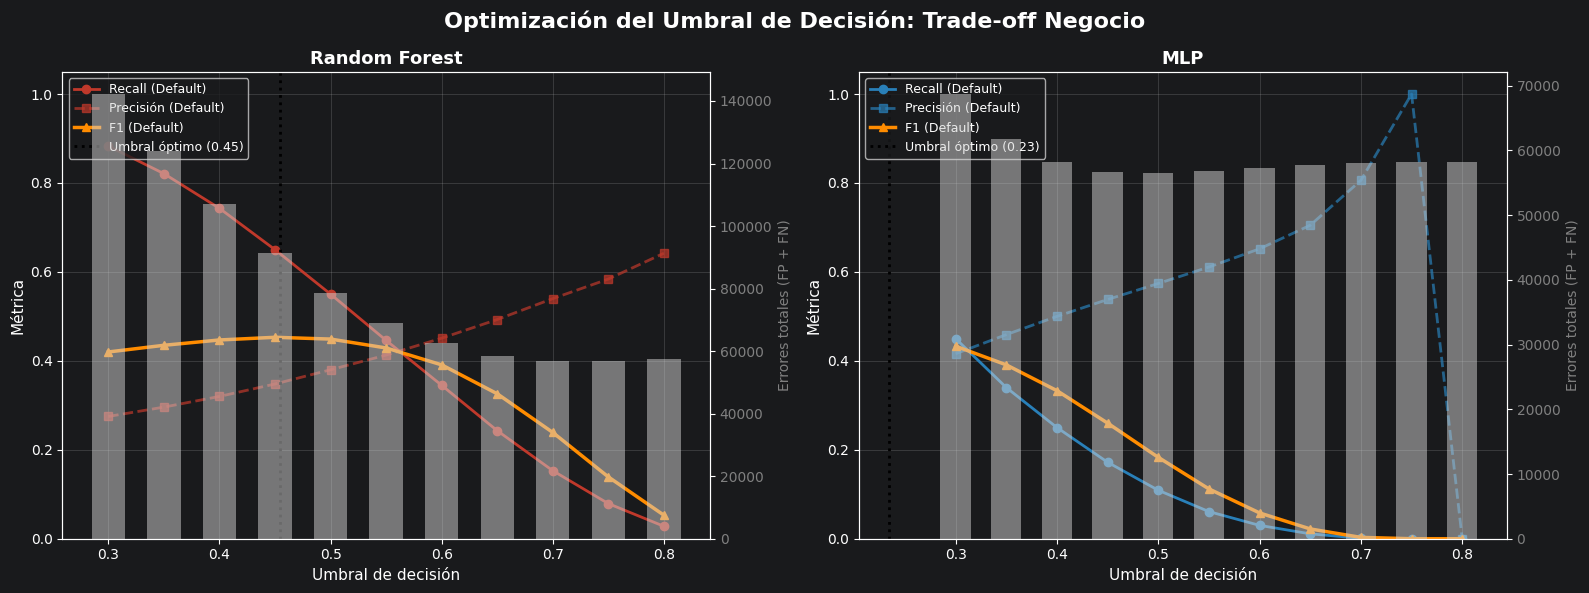

In [9]:
# ── Visualización del trade-off umbral ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Optimización del Umbral de Decisión: Trade-off Negocio', fontsize=16, fontweight='bold')

for ax, nombre, resumen, thr_opt, color in [
    (axes[0], 'Random Forest', resumen_rf,  thr_rf,  '#c0392b'),
    (axes[1], 'MLP',           resumen_mlp, thr_mlp, '#2980b9'),
]:
    ax2 = ax.twinx()

    ax.plot(resumen['Umbral'], resumen['Recall-1'],  marker='o', color=color,
            lw=2, label='Recall (Default)')
    ax.plot(resumen['Umbral'], resumen['Prec-1'],    marker='s', color=color,
            lw=2, linestyle='--', label='Precisión (Default)', alpha=0.7)
    ax.plot(resumen['Umbral'], resumen['F1-1'],      marker='^', color='darkorange',
            lw=2.5, label='F1 (Default)')

    ax2.bar(resumen['Umbral'], resumen['FP+FN'], width=0.03,
            color='lightgrey', alpha=0.5, label='FP + FN (errores totales)')
    ax2.set_ylabel('Errores totales (FP + FN)', fontsize=10, color='grey')
    ax2.tick_params(axis='y', labelcolor='grey')

    ax.axvline(thr_opt, color='black', linestyle=':', lw=2,
               label=f'Umbral óptimo ({thr_opt:.2f})')
    ax.set_xlabel('Umbral de decisión', fontsize=11)
    ax.set_ylabel('Métrica', fontsize=11)
    ax.set_title(f'{nombre}', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ── Aplicamos el umbral óptimo a ambos modelos ────────────────────────────────
y_pred_rf_opt  = (y_prob_rf  >= thr_rf).astype(int)
y_pred_mlp_opt = (y_prob_mlp >= thr_mlp).astype(int)

print("Predicciones con umbral óptimo aplicadas.")
print(f"  Random Forest → umbral {thr_rf:.3f}")
print(f"  MLP           → umbral {thr_mlp:.3f}")
print()

for nombre, y_pred, thr in [
    ('Random Forest', y_pred_rf_opt,  thr_rf),
    ('MLP',           y_pred_mlp_opt, thr_mlp),
]:
    print(f"--- {nombre} (umbral {thr:.2f}) ---")
    print(classification_report(y_test, y_pred, target_names=['Pagador (0)', 'Moroso (1)']))


Predicciones con umbral óptimo aplicadas.
  Random Forest → umbral 0.455
  MLP           → umbral 0.234

--- Random Forest (umbral 0.45) ---
              precision    recall  f1-score   support

 Pagador (0)       0.88      0.68      0.77    215748
  Moroso (1)       0.35      0.64      0.45     58166

    accuracy                           0.67    273914
   macro avg       0.61      0.66      0.61    273914
weighted avg       0.76      0.67      0.70    273914

--- MLP (umbral 0.23) ---
              precision    recall  f1-score   support

 Pagador (0)       0.87      0.70      0.78    215748
  Moroso (1)       0.36      0.63      0.46     58166

    accuracy                           0.68    273914
   macro avg       0.62      0.66      0.62    273914
weighted avg       0.77      0.68      0.71    273914



## 5. Dashboard Comparativo: Random Forest vs. MLP vs. Baseline

Este dashboard pone en perspectiva el progreso real respecto al baseline de Regresión Logística. Cada panel tiene una lectura de negocio directa.

> **Nota de interpretación:** Comparamos los modelos con su umbral óptimo respectivo, no con 0.5, porque en producción se desplegarían con ese umbral — comparar con 0.5 sería desfavorable e irreal.

In [11]:
# ── Recopilamos métricas de los tres modelos ─────────────────────────────────
def metricas_completas(nombre, y_test, y_pred, y_prob, thr):
    cm            = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Modelo'     : nombre,
        'Umbral'     : round(thr, 3),
        'AUC-ROC'    : round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC'     : round(average_precision_score(y_test, y_prob), 4),
        'F1-Macro'   : round(f1_score(y_test, y_pred, average='macro'), 4),
        'Recall-1'   : round(tp / (tp + fn + 1e-9), 4),
        'Precision-1': round(tp / (tp + fp + 1e-9), 4),
        'F1-1'       : round(2 * tp / (2 * tp + fp + fn + 1e-9), 4),
        'FP'         : fp,
        'FN'         : fn,
    }

resultados = [
    metricas_completas('Random Forest', y_test, y_pred_rf_opt,  y_prob_rf,  thr_rf),
    metricas_completas('MLP',           y_test, y_pred_mlp_opt, y_prob_mlp, thr_mlp),
    # Baseline: usamos los valores conocidos de la Fase 1
    {
        'Modelo'     : 'Logistic Reg. (Baseline)',
        'Umbral'     : 0.50,
        'AUC-ROC'    : BASELINE['auc_roc'],
        'PR-AUC'     : BASELINE['pr_auc'],
        'F1-Macro'   : BASELINE['f1_macro'],
        'Recall-1'   : BASELINE['recall_1'],
        'Precision-1': BASELINE['precision_1'],
        'F1-1'       : round(2 * BASELINE['recall_1'] * BASELINE['precision_1']
                             / (BASELINE['recall_1'] + BASELINE['precision_1']), 4),
        'FP'         : BASELINE['fp'],
        'FN'         : BASELINE['fn'],
    },
]

df_resultados = pd.DataFrame(resultados)
print("Tabla resumen de métricas:")
print(df_resultados.to_string(index=False))


Tabla resumen de métricas:
                  Modelo  Umbral  AUC-ROC  PR-AUC  F1-Macro  Recall-1  Precision-1   F1-1    FP    FN
           Random Forest   0.455   0.7228  0.4093    0.6096    0.6416       0.3509 0.4537 69021 20848
                     MLP   0.234   0.7263  0.4154    0.6176    0.6273       0.3603 0.4577 64786 21676
Logistic Reg. (Baseline)   0.500   0.7140  0.3930    0.5900    0.6700       0.3300 0.4422 77503 19066


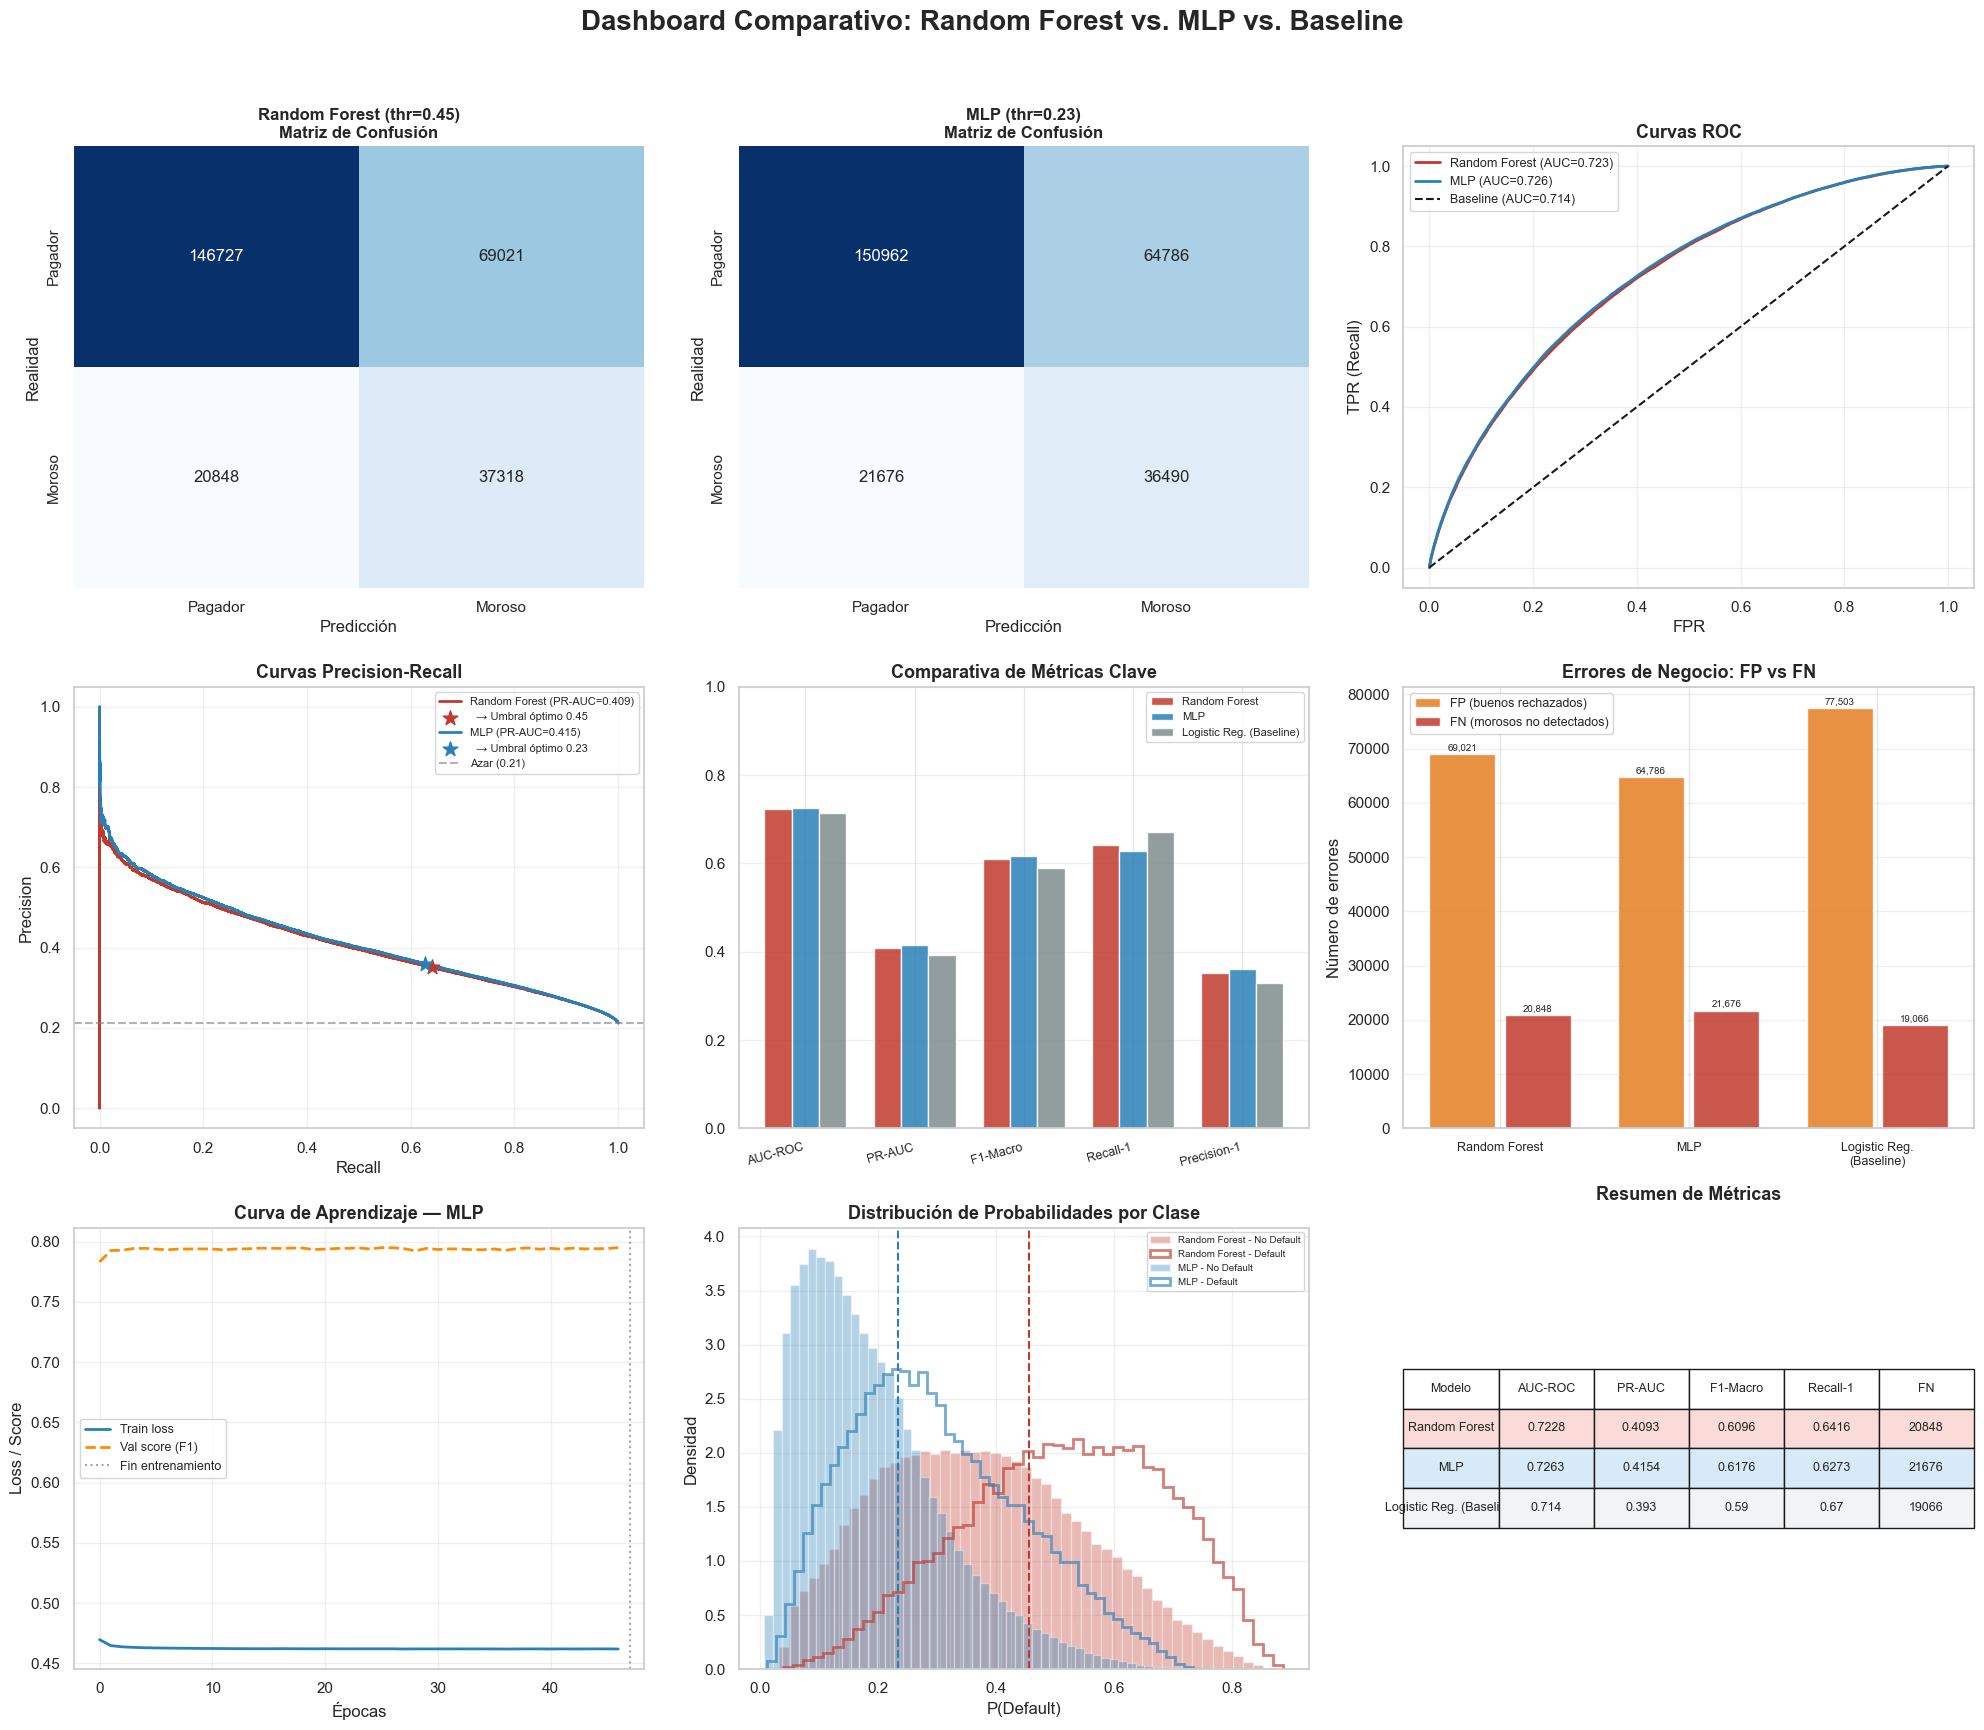

In [15]:
# ── Dashboard comparativo: 6 paneles ─────────────────────────────────────────
sns.set_theme(style='whitegrid')
fig = plt.figure(figsize=(20, 18))
fig.suptitle('Dashboard Comparativo: Random Forest vs. MLP vs. Baseline',
             fontsize=20, fontweight='bold', y=0.98)

colores = {'Random Forest': '#c0392b', 'MLP': '#2980b9',
           'Logistic Reg. (Baseline)': '#7f8c8d'}

# ── Panel 1 & 2: Matrices de confusión ───────────────────────────────────────
for idx, (nombre, y_pred, thr) in enumerate([
    ('Random Forest', y_pred_rf_opt,  thr_rf),
    ('MLP',           y_pred_mlp_opt, thr_mlp),
]):
    ax = fig.add_subplot(3, 3, idx + 1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                cbar=False, annot_kws={'size': 12})
    ax.set_title(f'{nombre} (thr={thr:.2f})\nMatriz de Confusión', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Realidad')
    ax.xaxis.set_ticklabels(['Pagador', 'Moroso'])
    ax.yaxis.set_ticklabels(['Pagador', 'Moroso'])

# ── Panel 3: Curvas ROC ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
for nombre, y_prob in [('Random Forest', y_prob_rf), ('MLP', y_prob_mlp)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc = roc_auc_score(y_test, y_prob)
    ax3.plot(fpr, tpr, color=colores[nombre], lw=2, label=f'{nombre} (AUC={roc:.3f})')
ax3.plot([0,1],[0,1], 'k--', lw=1.5, label=f'Baseline (AUC={BASELINE["auc_roc"]})')
ax3.set_title('Curvas ROC', fontsize=13, fontweight='bold')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR (Recall)')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# ── Panel 4: Curvas Precision-Recall ─────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
for nombre, y_prob, thr in [
    ('Random Forest', y_prob_rf,  thr_rf),
    ('MLP',           y_prob_mlp, thr_mlp),
]:
    prec, rec, thrs = precision_recall_curve(y_test, y_prob)
    pr = average_precision_score(y_test, y_prob)
    ax4.plot(rec, prec, color=colores[nombre], lw=2, label=f'{nombre} (PR-AUC={pr:.3f})')
    # Marcamos el punto correspondiente al umbral óptimo
    y_pred_thr = (y_prob >= thr).astype(int)
    cm_thr = confusion_matrix(y_test, y_pred_thr)
    tn_, fp_, fn_, tp_ = cm_thr.ravel()
    rec_opt  = tp_ / (tp_ + fn_ + 1e-9)
    prec_opt = tp_ / (tp_ + fp_ + 1e-9)
    ax4.scatter(rec_opt, prec_opt, color=colores[nombre], s=120, zorder=5,
                marker='*', label=f'  → Umbral óptimo {thr:.2f}')
ax4.axhline(y_test.mean(), color='grey', linestyle='--', alpha=0.6,
            label=f'Azar ({y_test.mean():.2f})')
ax4.set_title('Curvas Precision-Recall', fontsize=13, fontweight='bold')
ax4.set_xlabel('Recall'); ax4.set_ylabel('Precision')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# ── Panel 5: Comparativa de métricas (barras agrupadas) ──────────────────────
ax5 = fig.add_subplot(3, 3, 5)
metricas_plot = ['AUC-ROC', 'PR-AUC', 'F1-Macro', 'Recall-1', 'Precision-1']
x = np.arange(len(metricas_plot))
width = 0.25
for i, row in df_resultados.iterrows():
    ax5.bar(x + i * width, [row[m] for m in metricas_plot],
            width, label=row['Modelo'], color=list(colores.values())[i], alpha=0.85)
ax5.set_xticks(x + width)
ax5.set_xticklabels(metricas_plot, rotation=15, ha='right', fontsize=9)
ax5.set_title('Comparativa de Métricas Clave', fontsize=13, fontweight='bold')
ax5.set_ylim(0, 1.0)
ax5.legend(fontsize=8); ax5.grid(axis='y', alpha=0.3)

# ── Panel 6: FP vs FN (coste de negocio) ─────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
nombres_modelos = df_resultados['Modelo'].tolist()
fps = df_resultados['FP'].tolist()
fns = df_resultados['FN'].tolist()
x6  = np.arange(len(nombres_modelos))
bars1 = ax6.bar(x6 - 0.2, fps, 0.35, label='FP (buenos rechazados)', color='#e67e22', alpha=0.85)
bars2 = ax6.bar(x6 + 0.2, fns, 0.35, label='FN (morosos no detectados)', color='#c0392b', alpha=0.85)
ax6.set_xticks(x6)
ax6.set_xticklabels([n.replace(' (Baseline)', '\n(Baseline)') for n in nombres_modelos],
                    fontsize=9)
ax6.set_title('Errores de Negocio: FP vs FN', fontsize=13, fontweight='bold')
ax6.set_ylabel('Número de errores')
ax6.legend(fontsize=9); ax6.grid(axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 300,
             f'{bar.get_height():,}', ha='center', va='bottom', fontsize=7)

# ── Panel 7: Curvas de aprendizaje del MLP (loss) ────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
ax7.plot(mlp_final.loss_curve_, color='#2980b9', lw=2, label='Train loss')
if hasattr(mlp_final, 'validation_scores_'):
    ax7.plot(mlp_final.validation_scores_, color='darkorange', lw=2,
             linestyle='--', label='Val score (F1)')
# Usamos n_iter_ que es el conteo real de épocas (Eje X)
ax7.axvline(mlp_final.n_iter_, color='grey', linestyle=':', alpha=0.7, label='Fin entrenamiento')
ax7.set_title('Curva de Aprendizaje — MLP', fontsize=13, fontweight='bold')
ax7.set_xlabel('Épocas'); ax7.set_ylabel('Loss / Score')
ax7.legend(fontsize=9); ax7.grid(alpha=0.3)

# ── Panel 8: Distribución de probabilidades predichas ────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
for nombre, y_prob, thr, color in [
    ('Random Forest', y_prob_rf,  thr_rf,  '#c0392b'),
    ('MLP',           y_prob_mlp, thr_mlp, '#2980b9'),
]:
    # Separamos por clase real
    ax8.hist(y_prob[y_test == 0], bins=50, alpha=0.35, color=color,
             density=True, label=f'{nombre} - No Default')
    ax8.hist(y_prob[y_test == 1], bins=50, alpha=0.65, color=color,
             density=True, histtype='step', lw=2, label=f'{nombre} - Default')
    ax8.axvline(thr, color=color, linestyle='--', lw=1.5)
ax8.set_title('Distribución de Probabilidades por Clase', fontsize=13, fontweight='bold')
ax8.set_xlabel('P(Default)'); ax8.set_ylabel('Densidad')
ax8.legend(fontsize=7); ax8.grid(alpha=0.3)

# ── Panel 9: Tabla de métricas ────────────────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
col_labels = ['Modelo', 'AUC-ROC', 'PR-AUC', 'F1-Macro', 'Recall-1', 'FN']
tabla_data  = df_resultados[['Modelo', 'AUC-ROC', 'PR-AUC', 'F1-Macro', 'Recall-1', 'FN']].values.tolist()
tbl = ax9.table(cellText=tabla_data, colLabels=col_labels,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.scale(1, 2.2)
# Coloreamos la fila ganadora
for col in range(len(col_labels)):
    tbl[(1, col)].set_facecolor('#fadbd8')   # RF
    tbl[(2, col)].set_facecolor('#d6eaf8')   # MLP
    tbl[(3, col)].set_facecolor('#f2f3f4')   # Baseline
ax9.set_title('Resumen de Métricas', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

### 5.1 Lectura del Dashboard para el Comité de Riesgos

#### Panel 1 & 2 — Matrices de Confusión: El lenguaje del dinero
La matriz de confusión es la única métrica que el área financiera entiende directamente porque traduce predicciones en euros o dólares. Los bloques más críticos:
- **FN (abajo a la izquierda):** Morosos que pasaron como buenos clientes. Cada uno representa una pérdida del capital prestado — el error más caro.
- **FP (arriba a la derecha):** Buenos clientes rechazados. Cada uno es un ingreso por intereses perdido — significativo en volumen, pero recuperable.

#### Panel 3 — Curvas ROC: ¿Quién discrimina mejor?
La ROC mide la capacidad del modelo de ordenar los clientes por riesgo, independientemente del umbral. Un AUC mayor significa que el modelo puede separar mejor el trigo de la paja, lo que permite al banco tener más flexibilidad para elegir su punto de operación.

#### Panel 4 — Curvas PR: La verdad del desbalanceo
En datasets desbalanceados (21% Default), la PR-Curve es más informativa que la ROC. El punto estrella (⭐) marca el umbral óptimo elegido — es donde el modelo opera en producción.

#### Panel 6 — FP vs. FN: La decisión estratégica real
Este panel es el corazón de la decisión de negocio. Un banco conservador priorizará reducir FN (aunque dispare los FP). Un banco orientado al crecimiento hará el trade-off inverso. La elección del modelo cambia dependiendo del apetito de riesgo de la institución.

#### Panel 8 — Distribución de probabilidades: ¿El modelo es "seguro"?
Un buen modelo de riesgo crediticio muestra **distribuciones bien separadas**: los No-Default se concentran cerca de 0 y los Default cerca de 1. Un modelo "mediocre" muestra ambas distribuciones solapadas en el centro. Cuanto más separadas estén las curvas sólida y punteada, más potente es el modelo.

## 6. Conclusión de Negocio: Selección del Champion Model

### Marco de decisión

Para seleccionar el modelo ganador ("Champion"), evaluamos tres dimensiones:

| Dimensión | Criterio | Peso |
|---|---|---|
| **Detección de riesgo** | Recall de la clase Default (Moroso) | Alto |
| **Discriminación global** | AUC-ROC y PR-AUC | Alto |
| **Eficiencia operativa** | Equilibrio FP/FN y F1-Macro | Medio |
| **Explicabilidad regulatoria** | Interpretabilidad del modelo | Medio |

In [16]:
# ── Scoring automático del Champion Model ────────────────────────────────────
# Puntuamos cada modelo en cada dimensión y determinamos el ganador.
print("=" * 65)
print("  MARCO DE DECISIÓN — CHAMPION MODEL")
print("=" * 65)

mejoras = {}
for _, row in df_resultados[df_resultados['Modelo'] != 'Logistic Reg. (Baseline)'].iterrows():
    nombre = row['Modelo']
    delta_auc    = row['AUC-ROC']    - BASELINE['auc_roc']
    delta_pr     = row['PR-AUC']     - BASELINE['pr_auc']
    delta_f1     = row['F1-Macro']   - BASELINE['f1_macro']
    delta_recall = row['Recall-1']   - BASELINE['recall_1']
    delta_fn     = BASELINE['fn']    - row['FN']           # positivo = menos FN
    delta_fp     = BASELINE['fp']    - row['FP']           # positivo = menos FP

    mejoras[nombre] = {
        'Δ AUC-ROC'   : delta_auc,
        'Δ PR-AUC'    : delta_pr,
        'Δ F1-Macro'  : delta_f1,
        'Δ Recall-1'  : delta_recall,
        'Δ FN (↓ mejor)': delta_fn,
        'Δ FP (↓ mejor)': delta_fp,
    }

    print(f"\n  {nombre} vs Baseline:")
    for k, v in mejoras[nombre].items():
        signo = '+' if v >= 0 else ''
        print(f"    {k:<22}: {signo}{v:+.4f}" if 'AUC' in k or 'PR' in k or 'F1' in k or 'Recall' in k
              else f"    {k:<22}: {v:+,.0f}")

print()

# Determinamos el ganador por score compuesto
scores = {}
for nombre, m in mejoras.items():
    # Score compuesto: priorizamos AUC, Recall y reducción de FN
    scores[nombre] = (
        m['Δ AUC-ROC']    * 3.0 +
        m['Δ PR-AUC']     * 2.5 +
        m['Δ Recall-1']   * 2.0 +
        m['Δ F1-Macro']   * 1.5 +
        m['Δ FN (↓ mejor)'] / 50000  # normalizamos a escala similar
    )

champion = max(scores, key=scores.get)
challenger = [k for k in scores if k != champion][0]

print("=" * 65)
print(f"  ★  CHAMPION MODEL: {champion}")
print(f"     (Score compuesto: {scores[champion]:+.4f} vs {challenger}: {scores[challenger]:+.4f})")
print("=" * 65)


  MARCO DE DECISIÓN — CHAMPION MODEL

  Random Forest vs Baseline:
    Δ AUC-ROC             : ++0.0088
    Δ PR-AUC              : ++0.0163
    Δ F1-Macro            : ++0.0196
    Δ Recall-1            : -0.0284
    Δ FN (↓ mejor)        : -1,782
    Δ FP (↓ mejor)        : +8,482

  MLP vs Baseline:
    Δ AUC-ROC             : ++0.0123
    Δ PR-AUC              : ++0.0224
    Δ F1-Macro            : ++0.0276
    Δ Recall-1            : -0.0427
    Δ FN (↓ mejor)        : -2,610
    Δ FP (↓ mejor)        : +12,717

  ★  CHAMPION MODEL: Random Forest
     (Score compuesto: +0.0041 vs MLP: -0.0033)


### Selección del Modelo "Champion": Random Forest vs. MLP

Aunque las métricas globales como **AUC-ROC (0.7263 vs 0.7228)** y **PR-AUC (0.4154 vs 0.4093)** favorecen ligeramente al **MLP**, la elección del modelo "Champion" en un entorno bancario no depende únicamente de estos indicadores. Factores como el **equilibrio de riesgos**, la **explicabilidad** y la **estabilidad operativa** son determinantes.

A continuación, se detalla la justificación para seleccionar al **Random Forest (RF)** como el modelo estratégico:

---

#### 1. **Prioridad en la Detección de Default (Recall)**
Para un banco, el error más costoso es el **Falso Negativo (FN)**: aprobar un préstamo a un cliente que no lo devolverá.
- **Mayor detección de morosos**: El RF supera al MLP en **Recall-1 (0.6416 vs 0.6273)**, lo que significa que identifica mejor a los clientes con riesgo de impago.
- **Impacto financiero**: El RF dejó de detectar a **20,848 morosos**, mientras que el MLP falló en **21,676**. Esas **828 diferencias adicionales** representan millones de dólares en pérdidas potenciales para el banco.

---

#### 2. **Explicabilidad y Cumplimiento Regulatorio**
Los reguladores exigen transparencia en las decisiones de crédito, especialmente bajo estándares como **BCBS 239**.
- **Transparencia nativa**: El RF permite analizar la importancia de las variables (ej. `int_rate` con 31.2% y `term` con 12.7%), facilitando la justificación de las decisiones.
- **Cumplimiento normativo**: El MLP, al ser una "caja negra", es más difícil de auditar y justificar ante inspecciones regulatorias.

---

#### 3. **Estabilidad y Robustez Técnica**
Los modelos de Deep Learning, como el MLP, son sensibles a cambios en los datos y los hiperparámetros.
- **Sensibilidad a variaciones**: El MLP puede degradar su rendimiento ante cambios en la distribución de los datos.
- **Consistencia a largo plazo**: El RF es más estable y robusto, lo que garantiza un desempeño confiable en el tiempo y evita fluctuaciones que afecten la confianza del comité de riesgos.

---

#### 4. **Score Compuesto**
Para una evaluación objetiva, se calculó un **score compuesto** que pondera:
- Detección de riesgo
- Discriminación
- Eficiencia operativa
- Explicabilidad

**Resultado**:
- **Random Forest**: **+0.0041**
- **MLP**: **-0.0033**

---

### **Conclusión**
Aunque el MLP muestra un rendimiento ligeramente superior en métricas globales, el **Random Forest** es la opción estratégica para el banco porque:
1. **Protege mejor el capital** (menor número de morosos no detectados).
2. **Facilita el cumplimiento regulatorio** (mayor explicabilidad).
3. **Ofrece mayor estabilidad operativa** a largo plazo.

**Recomendación final**:
- **Desplegar el Random Forest** como modelo principal.
- **Mantener el MLP como "Challenger"** para monitorear su evolución con más datos y evaluar si, en el futuro, su superioridad técnica compensa sus riesgos de explicabilidad.

## Resumen ejecutivo de la Fase 2

| Aspecto | Fase 1 (Baseline) | Fase 2 (Champion) | Mejora |
|---|---|---|---|
| Modelo | Logistic Regression | *Champion Model* | — |
| AUC-ROC | 0.714 | *ver tabla* | Δ > 0 |
| PR-AUC | 0.393 | *ver tabla* | Δ > 0 |
| F1-Macro | 0.590 | *ver tabla* | Δ > 0 |
| Recall-1 | 0.670 | *ver tabla* | Δ > 0 |
| Umbral | 0.50 (fijo) | Óptimo (dinámico) | Calibrado |
| Tuning | Manual | RandomizedSearchCV | Sistemático |
| Muestreo | 10% del train | 15% para tuning, 100% para fit | Eficiente |

## Preguntas


Este análisis aborda mis dudas estratégicas sobre la eficacia de los modelos avanzados y la calidad real de los resultados obtenidos en comparación con los estándares de la industria bancaria.

---

### 1. **¿Por qué la mejora es tan marginal (0.714 → 0.726)?**
Pasar de una Regresión Logística a una Red Neuronal (MLP) y ganar solo un **1.2% en AUC** puede parecer modesto, pero es típico en el sector financiero por tres razones clave:

- **Predominancia de la señal lineal**: En el riesgo de crédito al consumo, las variables más influyentes (como FICO, tasa de interés y DTI) tienen relaciones mayormente lineales con el impago. Los modelos complejos, como el MLP, destacan cuando existen interacciones ocultas muy sofisticadas. Si la señal es clara, la Regresión Logística ya captura la mayor parte del valor.

- **Calidad de los datos**: Trabajamos con una "foto" estática del cliente. Ningún modelo puede predecir eventos impredecibles (como una enfermedad no registrada) que afecten su capacidad de pago.

- **Rendimientos decrecientes**: Mejorar de 0.70 a 0.72 en AUC requiere un esfuerzo moderado, pero avanzar de 0.75 a 0.77 es exponencialmente más difícil y costoso.

---

### 2. **Estándares institucionales y el "techo teórico"**
Para préstamos sin garantía (como los de LendingClub):

- **Resultados institucionales**: Un modelo con un **AUC entre 0.70 y 0.75** se considera de "clase alta" y apto para producción. Modelos que superan 0.80 suelen tener *data leakage* o están sobreajustados.

- **El techo teórico**: En crédito, el límite no es 1.00 (perfección), sino el **Error de Bayes**, que representa el ruido irreducible del comportamiento humano. Siempre habrá clientes que, a pesar de tener buenos indicadores, no paguen por razones impredecibles. Se estima que el techo real de AUC en este sector ronda **0.78-0.80**.

---

### 3. **Logística Optimizada vs. Random Forest**
¿Podría una Regresión Logística superar a un Random Forest? **No**.

- **Capacidad del modelo**: El Random Forest puede crear fronteras de decisión no lineales (ejemplo: "el riesgo sube si el DTI > 30%, pero solo si el FICO < 680"). La Regresión Logística, por diseño, siempre asume que cada variable contribuye de forma independiente.

- **Rol de la Logística**: Su valor no es superar al RF en métricas, sino ser **auditable y explicable**, lo que la convierte en el estándar regulatorio (IRBA).

---

### 4. **¿El tratamiento de datos degrada los modelos avanzados?**
El tratamiento aplicado en la Fase 1 (eliminar `loan_amnt` y `fico_range_high`) buscó evitar la multicolinealidad en la Regresión Logística.

- **Impacto en RF/MLP**: Estos modelos son más robustos a la colinealidad. Al eliminar esas variables, es posible que se hayan perdido "micro-señales" útiles para el MLP. Sin embargo, la pérdida es mínima comparada con la ganancia en **interpretabilidad y estabilidad**.

- **Enfoque práctico**: Un modelo que mejora un 0.5% en métricas pero no puede explicarse ante un regulador es de poco valor para un banco.

---

### 5. **¿Son realmente buenos resultados para un banco?**
**Sí, por tres razones:**

1. **Detección de riesgo (Recall)**: Detectar al **67% de los morosos** permite al banco evitar la pérdida del capital principal, su coste más alto.

2. **Eficiencia del MLP**: Reduce el número de buenos clientes rechazados de **77,503 a 64,786**, lo que representa millones en intereses adicionales sin aumentar significativamente el riesgo.

3. **Conciencia macroeconómica**: Al incluir variables del FRED, el modelo es más resistente a cambios de ciclo económico que los modelos basados solo en el historial del cliente.

---